In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

I0000 00:00:1781107592.986052   35277 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781107593.155218   35277 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781107595.567339   35277 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv(
    "/workspaces/farmer_crop_climate_mismatch_system/datasets/Crop_recommendation.csv"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
X = df.drop("label", axis=1)

y_raw = df["label"]

print(X.shape)
print(y_raw.shape)

(2200, 7)
(2200,)


In [4]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y_raw)

num_classes = len(label_encoder.classes_)

print("Number of Classes:", num_classes)

Number of Classes: 22


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.35,
    random_state=42
)

In [6]:
scaler = joblib.load(
    "/workspaces/farmer_crop_climate_mismatch_system/models/neural_network_scaler.pkl"
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

/workspaces/farmer_crop_climate_mismatch_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/workspaces/farmer_crop_climate_mismatch_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [7]:
model = load_model(
    "/workspaces/farmer_crop_climate_mismatch_system/models/neural_network_model.h5"
)

print("Model Loaded Successfully")

E0000 00:00:1781107606.898257   35277 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model Loaded Successfully


In [8]:
prediction_probs = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(
    prediction_probs,
    axis=1
)

In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy : {accuracy*100:.2f}%"
)

Accuracy : 96.75%


In [10]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print(
    f"Precision : {precision*100:.2f}%"
)

Precision : 97.17%


In [11]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print(
    f"Recall : {recall*100:.2f}%"
)

Recall : 96.75%


In [12]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(
    f"F1 Score : {f1*100:.2f}%"
)

F1 Score : 96.69%


In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        32
           2       1.00      0.97      0.98        30
           3       1.00      1.00      1.00        42
           4       1.00      1.00      1.00        36
           5       1.00      0.97      0.99        34
           6       0.97      1.00      0.99        34
           7       1.00      1.00      1.00        29
           8       0.71      0.95      0.81        37
           9       0.95      0.98      0.96        41
          10       0.88      0.97      0.92        31
          11       1.00      0.97      0.99        35
          12       1.00      1.00      1.00        37
          13       0.97      0.93      0.95        40
          14       1.00      1.00      1.00        34
          15       1.00      1.00      1.00        28
          16       1.00      1.00      1.00        29
          17       0.97    

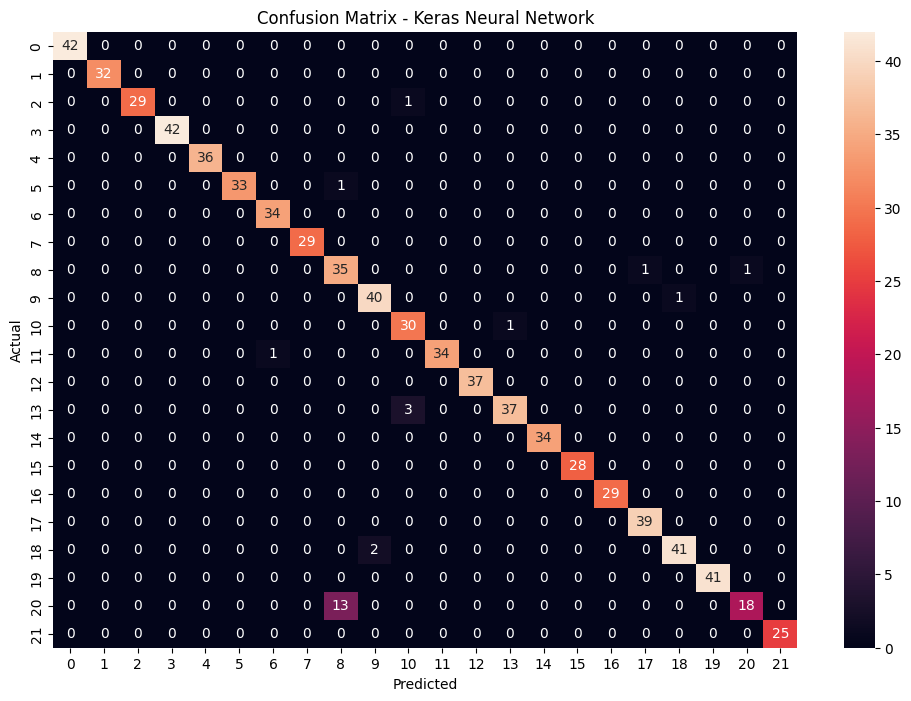

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix - Keras Neural Network"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [15]:
train_probs = model.predict(
    X_train_scaled,
    verbose=0
)

train_pred = np.argmax(
    train_probs,
    axis=1
)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

print(
    f"Training Accuracy : {train_accuracy*100:.2f}%"
)

Training Accuracy : 98.18%


In [16]:
gap = (
    train_accuracy -
    accuracy
) * 100

print(
    f"Testing Accuracy : {accuracy*100:.2f}%"
)

print(
    f"Accuracy Gap : {gap:.2f}%"
)

if abs(gap) < 1:
    print("✅ Well Fitted Model")

elif gap > 5:
    print("⚠ Overfitting Detected")

else:
    print("⚠ Needs Further Analysis")

Testing Accuracy : 96.75%
Accuracy Gap : 1.43%
⚠ Needs Further Analysis


In [17]:
samples = df.sample(
    10,
    random_state=42
)

correct = 0

for _, row in samples.iterrows():

    actual_crop = row["label"]

    features = row.drop("label")

    scaled = scaler.transform(
        [features]
    )

    prediction = model.predict(
        scaled,
        verbose=0
    )

    predicted_crop = label_encoder.inverse_transform(
        [np.argmax(prediction)]
    )[0]

    print(
        f"Actual: {actual_crop} | Predicted: {predicted_crop}"
    )

    if actual_crop == predicted_crop:
        correct += 1

Actual: muskmelon | Predicted: muskmelon
Actual: watermelon | Predicted: watermelon
Actual: papaya | Predicted: papaya
Actual: papaya | Predicted: papaya
Actual: apple | Predicted: apple
Actual: mango | Predicted: mango
Actual: apple | Predicted: apple
Actual: mothbeans | Predicted: mothbeans
Actual: mungbean | Predicted: mungbean
Actual: lentil | Predicted: lentil


In [18]:
print(
    f"\nCorrect Predictions: {correct}/10"
)

print(
    f"Validation Accuracy: {(correct/10)*100:.2f}%"
)


Correct Predictions: 10/10
Validation Accuracy: 100.00%


In [19]:
summary = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Accuracy"
    ],
    "Value":[
        round(accuracy*100,2),
        round(precision*100,2),
        round(recall*100,2),
        round(f1*100,2),
        round(train_accuracy*100,2)
    ]
})

summary

,Metric,Value
0,Accuracy,96.75
1,Precision,97.17
2,Recall,96.75
3,F1 Score,96.69
4,Training Accuracy,98.18
